# Objective: Use patient data from the Cleveland Clinic Foundation to determine what factors are significantly associated with heart disease diagnosis.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
heart = pd.read_csv('heart_disease.csv')

## Inspect the Data

In [3]:
print('Here\'s a preview of the heart disease dataset:')
print(heart.head())

Here's a preview of the heart disease dataset:
    age     sex  trestbps   chol                cp  exang  fbs  thalach  \
0  63.0    male     145.0  233.0    typical angina    0.0  1.0    150.0   
1  67.0    male     160.0  286.0      asymptomatic    1.0  0.0    108.0   
2  67.0    male     120.0  229.0      asymptomatic    1.0  0.0    129.0   
3  37.0    male     130.0  250.0  non-anginal pain    0.0  0.0    187.0   
4  41.0  female     130.0  204.0   atypical angina    0.0  0.0    172.0   

  heart_disease  
0       absence  
1      presence  
2      presence  
3       absence  
4       absence  


## Predictors of Heart Disease

### Is thalach (maximum heart rate achieved during exercise) associated with whether a patient will ultimately be diagnosed with heart disease? 

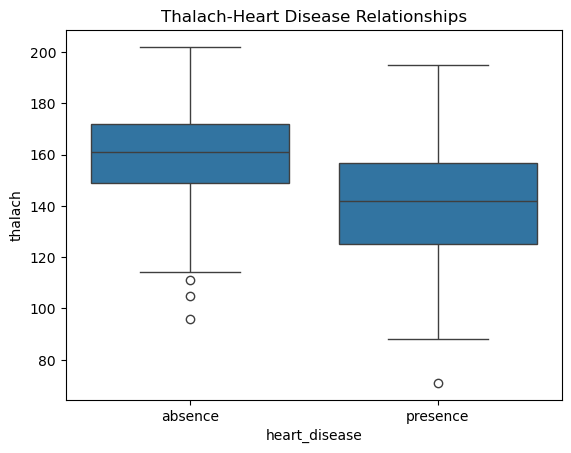

In [4]:
sns.boxplot(data=heart, x='heart_disease', y='thalach')
plt.title('Thalach-Heart Disease Relationships')
plt.show()

**Verdict:** Thalach is greater for patients that do not have heart disease.

### Is the average thalach of a heart disease patient significantly different from that of a person without heart disease?

In [5]:
# Save values for thalach among patients who have (or do not have) heart disease
thalach_hd = heart['thalach'][heart['heart_disease']=='presence']
thalach_no_hd = heart['thalach'][heart['heart_disease']=='absence']

In [6]:
# Find mean and median differences
mean_diff_thalach = np.mean(thalach_no_hd) - np.mean(thalach_hd)
print('Difference in mean thalach:', mean_diff_thalach)
med_diff_thalach = np.median(thalach_no_hd) - np.median(thalach_hd)
print('Difference in median thalach:', med_diff_thalach)

Difference in mean thalach: 19.11905597473242
Difference in median thalach: 19.0


In [7]:
# In this scenario, the ideal statistical test is the two-sample t-test
from scipy.stats import ttest_ind
tstat_thalach, pval_thalach = ttest_ind(thalach_hd, thalach_no_hd)

In [22]:
print(f'Thalach p-value: {pval_thalach*100.0}%')

Thalach p-value: 3.456964908430172e-12%


**Verdict:** The two-sample t-test above indicates that thalach levels and heart disease diagnosis are statistically significant. In fact, patients diagnosed with heart disease had lower thalach on average than patients who do not have heart disease.

### Investigate the relationship between heart disease and another quantitative variable.

In [9]:
# My choice: cholesterol levels
chol_hd = heart['chol'][heart['heart_disease']=='presence']
chol_no_hd = heart['chol'][heart['heart_disease']=='absence']

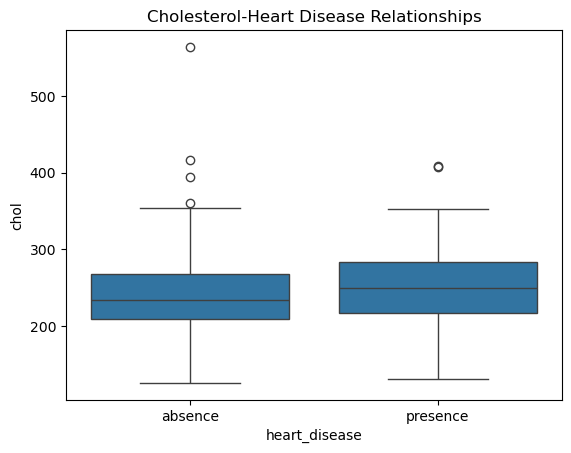

In [10]:
sns.boxplot(data=heart, x='heart_disease', y='chol')
plt.title('Cholesterol-Heart Disease Relationships')
plt.show()

In [11]:
# Find mean and median differences
mean_diff_chol = np.mean(chol_no_hd) - np.mean(chol_hd)
print('Difference in mean cholesterol levels:', mean_diff_chol)
med_diff_chol = np.median(chol_no_hd) - np.median(chol_hd)
print('Difference in median cholesterol levels:', med_diff_chol)

Difference in mean cholesterol levels: -8.834576241445887
Difference in median cholesterol levels: -14.5


In [12]:
# In this scenario, the ideal statistical test is the two-sample t-test
from scipy.stats import ttest_ind
tstat_chol, pval_chol = ttest_ind(chol_hd, chol_no_hd)

In [13]:
print(f'Cholesterol p-value: {pval_chol*100.0}%')

The difference in average cholesterol levels between people with heart disease and people who do not is not significant.


**Verdict:** The one-sample t-test above indicates that cholesterol levels are not strongly associated with heart disease.

## Chest Pain and Max Heart Rate

### Is thalach associated with the kind of chest pains a person experiences?

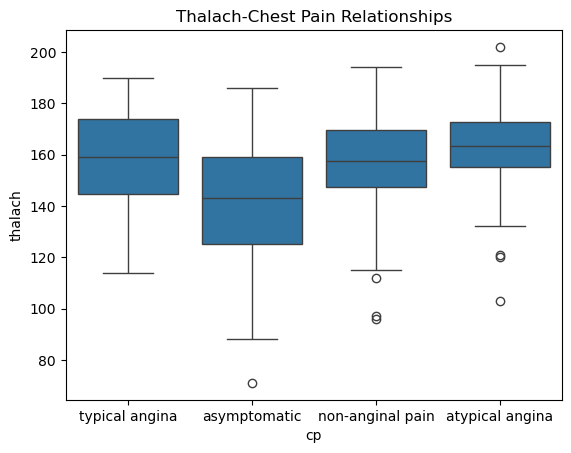

In [14]:
sns.boxplot(data=heart, x='cp', y='thalach')
plt.title('Thalach-Chest Pain Relationships')
plt.show()

**Verdict:** It does not look like thalach has a significant relationship with chest pains.

### Conduct a single hypothesis test on chest pain and thalach.

In [15]:
# Save the values of thalach for patients who experienced each type of chest pain
thalach_typical = heart['thalach'][heart['cp']=='typical angina']
thalach_asymptom = heart['thalach'][heart['cp']=='asymptomatic']
thalach_nonangin = heart['thalach'][heart['cp']=='non-anginal pain']
thalach_atypical = heart['thalach'][heart['cp']=='atypical angina']

In [16]:
from scipy.stats import f_oneway
stat_cp, pval_cp = f_oneway(thalach_typical, thalach_asymptom, thalach_nonangin, thalach_atypical)

In [17]:
print(f'Chest pain p-value: {pval_cp*100.0}%.')

There is at least one pair of chest pain categories for which people experiencing those types have significantly difference thalach levels.


**Verdict:** The ANOVA test above indicates that there is at least one pair of chest pain categories associated with thalach levels. Tukey's test will explore which chest pains those are.

### Conduct Tukey's test.

In [18]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [19]:
results = pairwise_tukeyhsd(endog=heart['thalach'], groups=heart['cp'])
print(results)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
    asymptomatic  atypical angina  21.7394    0.0  12.7442 30.7347   True
    asymptomatic non-anginal pain  14.7264    0.0   7.2583 22.1945   True
    asymptomatic   typical angina   15.276 0.0081   2.9707 27.5812   True
 atypical angina non-anginal pain   -7.013 0.2481 -16.7587  2.7327  False
 atypical angina   typical angina  -6.4635 0.6213 -20.2702  7.3432  False
non-anginal pain   typical angina   0.5495 0.9995 -12.3145 13.4136  False
-------------------------------------------------------------------------


**Verdict:** The following pairs are statistically different:
* asymptomatic-atypical angina
* asymptomatic-non-anginal pain
* asymptomatic-typical angina 

## Heart Disease and Chest Pain

In [24]:
# Contingency table
Xtab = pd.crosstab(heart['cp'], heart['heart_disease'])
print('Chest Pain-Heart Disease Contingency Table:')
print(Xtab)

Chest Pain-Heart Disease Contingency Table:
heart_disease     absence  presence
cp                                 
asymptomatic           39       105
atypical angina        41         9
non-anginal pain       68        18
typical angina         16         7


In [28]:
# Find out if there really is no association between chest pain and heart disease
from scipy.stats import chi2_contingency
chi2, pval, dof, exp = chi2_contingency(Xtab)
print(f'P-value between heart disease and chest pain: {pval*100.0}%.')

P-value between heart disease and chest pain: 1.2517106007837527e-15%.


**Verdict:** The chi-square test suggests a statistically significant association between chest-pain type and heart disease diagnosis. However, this does not guarantee that chest pain causes heart disease.